# EDA — Mercado de Gado Gordo (Boi e Novilha)

**Fonte:** Cotações diárias da [Scot Consultoria](https://www.scotconsultoria.com.br), coletadas via Gado-Scraper
**Período:** dezembro/2025 → junho/2026
**Variáveis principais:** `preco_vista` (R$/arroba) e `preco_30d` por praça pecuária

Este notebook explora o histórico de preços, identifica padrões temporais, regionais e a relação entre os dois ativos (boi gordo e novilha).

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.signal import find_peaks
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='husl')

DATA_DIR = Path('../data')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print('Setup OK — figuras serão salvas em:', FIG_DIR.resolve())

Setup OK — figuras serão salvas em: /home/Dom1ng0s/dev/Gado-Scraper/notebooks/figures


---
## 1 · Carregamento e Diagnóstico

Carregamos os dois CSVs gerados pelo pipeline de histórico e inspecionamos tipos, shape e integridade.

In [2]:
boi = pd.read_csv(DATA_DIR / 'historico_boi.csv', parse_dates=['data'])
nov = pd.read_csv(DATA_DIR / 'historico_novilha.csv', parse_dates=['data'])

print('=== BOI ===')
print(f'Shape : {boi.shape}')
print(f'Colunas: {list(boi.columns)}')
display(boi.head(3))

print('\n=== NOVILHA ===')
print(f'Shape : {nov.shape}')
print(f'Colunas: {list(nov.columns)}')
display(nov.head(3))

=== BOI ===
Shape : (4884, 5)
Colunas: ['praca', 'preco_vista', 'preco_30d', 'variacao', 'data']


,praca,preco_vista,preco_30d,variacao,data
0,Roraima,293.0,296.0,-7.75,2025-12-27
1,SP Barretos,317.5,321.0,0.00,2025-12-27
2,SP Araçatuba,317.5,321.0,0.00,2025-12-27



=== NOVILHA ===
Shape : (4851, 4)
Colunas: ['praca', 'preco_vista', 'preco_30d', 'data']


,praca,preco_vista,preco_30d,data
0,Roraima,271.0,274.0,2025-12-27
1,SP Barretos,308.5,312.0,2025-12-27
2,SP Araçatuba,308.5,312.0,2025-12-27


In [3]:
print('--- Tipos de dados ---')
print('\nBoi:\n', boi.dtypes)
print('\nNovilha:\n', nov.dtypes)

print('\n--- Estatísticas básicas (preco_vista) ---')
print('\nBoi:\n', boi['preco_vista'].describe().round(2))
print('\nNovilha:\n', nov['preco_vista'].describe().round(2))

--- Tipos de dados ---

Boi:
 praca                     str
preco_vista           float64
preco_30d             float64
variacao              float64
data           datetime64[us]
dtype: object

Novilha:
 praca                     str
preco_vista           float64
preco_30d             float64
data           datetime64[us]
dtype: object

--- Estatísticas básicas (preco_vista) ---

Boi:
 count    4884.00
mean      303.15
std        76.49
min        10.60
25%       304.00
50%       321.00
75%       338.50
max       360.50
Name: preco_vista, dtype: float64

Novilha:
 count    4851.00
mean      289.62
std        73.14
min        10.20
25%       291.50
50%       306.50
75%       322.00
max       343.50
Name: preco_vista, dtype: float64


In [4]:
print('=== VALORES NULOS ===')
print('\nBoi:')
print(boi.isnull().sum())
print('\nNovilha:')
print(nov.isnull().sum())

dups_b = boi.duplicated(subset=['data', 'praca']).sum()
dups_n = nov.duplicated(subset=['data', 'praca']).sum()
print(f'\n=== DUPLICATAS (data + praça) ===')
print(f'  Boi    : {dups_b}')
print(f'  Novilha: {dups_n}')

=== VALORES NULOS ===

Boi:
praca          0
preco_vista    0
preco_30d      0
variacao       0
data           0
dtype: int64

Novilha:
praca          0
preco_vista    0
preco_30d      0
data           0
dtype: int64

=== DUPLICATAS (data + praça) ===
  Boi    : 66
  Novilha: 66


In [5]:
dias_boi = boi['data'].nunique()
dias_nov = nov['data'].nunique()

print('=== PRAÇAS COM REGISTROS INCOMPLETOS ===')
contagem_b = boi.groupby('praca')['data'].count()
incompletas_b = contagem_b[contagem_b < dias_boi]
if len(incompletas_b):
    print(f'\nBoi (esperado {dias_boi} registros):')
    print(incompletas_b.sort_values())
else:
    print(f'\nBoi: todas as praças têm {dias_boi} registros ✓')

contagem_n = nov.groupby('praca')['data'].count()
incompletas_n = contagem_n[contagem_n < dias_nov]
if len(incompletas_n):
    print(f'\nNovilha (esperado {dias_nov} registros):')
    print(incompletas_n.sort_values())
else:
    print(f'\nNovilha: todas as praças têm {dias_nov} registros ✓')

=== PRAÇAS COM REGISTROS INCOMPLETOS ===

Boi: todas as praças têm 146 registros ✓

Novilha: todas as praças têm 145 registros ✓


In [6]:
for nome, df in [('BOI', boi), ('NOVILHA', nov)]:
    n_dias   = df['data'].nunique()
    n_pracas = df['praca'].nunique()
    dt_ini   = df['data'].min().strftime('%d/%m/%Y')
    dt_fim   = df['data'].max().strftime('%d/%m/%Y')
    print(f'{nome}: {n_dias} dias coletados, {n_pracas} praças, período de {dt_ini} até {dt_fim}')

BOI: 146 dias coletados, 33 praças, período de 27/12/2025 até 07/06/2026
NOVILHA: 145 dias coletados, 33 praças, período de 27/12/2025 até 07/06/2026


**Diagnóstico:** Os dois datasets cobrem o mesmo período e as mesmas 33 praças.
Verificamos nulos, duplicatas e consistência antes de prosseguir para a limpeza.

---
## 2 · Limpeza

Aplicamos três decisões de limpeza, documentadas individualmente:

1. **Conversão de data** — já feita via `parse_dates` no carregamento
2. **Remoção de duplicatas** — mantém o registro mais recente por `(data, praça)`
3. **Tratamento de outliers** — preços ≤ 0 ou ≥ 1 000 R$/arroba são fisicamente impossíveis e removidos

In [7]:
# 1. Data já é datetime — verificação (pandas 2+ usa datetime64[us])
assert pd.api.types.is_datetime64_any_dtype(boi['data']), 'data não é datetime!'
assert pd.api.types.is_datetime64_any_dtype(nov['data']), 'data não é datetime!'
print('Tipo data OK:', boi['data'].dtype)

Tipo data OK: datetime64[us]


In [8]:
# 2. Duplicatas: keep='last' preserva o scrape mais recente caso haja reprocessamento
antes_b = len(boi); antes_n = len(nov)
boi = boi.drop_duplicates(subset=['data', 'praca'], keep='last').reset_index(drop=True)
nov = nov.drop_duplicates(subset=['data', 'praca'], keep='last').reset_index(drop=True)
print(f'Duplicatas removidas — Boi: {antes_b - len(boi)} | Novilha: {antes_n - len(nov)}')

Duplicatas removidas — Boi: 66 | Novilha: 66


In [9]:
# 3. Outliers: preço físico impossível
mask_b = boi['preco_vista'].between(50, 1000, inclusive='both') & boi['preco_vista'].notna()
mask_n = nov['preco_vista'].between(50, 1000, inclusive='both') & nov['preco_vista'].notna()

removed_b = (~mask_b).sum()
removed_n = (~mask_n).sum()

if removed_b:
    print('Outliers Boi removidos:')
    print(boi[~mask_b][['data','praca','preco_vista']])
if removed_n:
    print('Outliers Novilha removidos:')
    print(nov[~mask_n][['data','praca','preco_vista']])

boi = boi[mask_b].reset_index(drop=True)
nov = nov[mask_n].reset_index(drop=True)
print(f'Outliers removidos — Boi: {removed_b} | Novilha: {removed_n}')
print(f'Shape final      — Boi: {boi.shape} | Novilha: {nov.shape}')

Outliers Boi removidos:
           data            praca  preco_vista
12   2025-12-27    RS Oeste (kg)        10.60
13   2025-12-27  RS Pelotas (kg)        10.70
33   2025-12-28  RS Pelotas (kg)        10.70
34   2025-12-28    RS Oeste (kg)        10.60
68   2025-12-29  RS Pelotas (kg)        10.70
...         ...              ...          ...
4722 2026-06-05    RS Oeste (kg)        12.30
4753 2026-06-06  RS Pelotas (kg)        12.35
4754 2026-06-06    RS Oeste (kg)        12.30
4786 2026-06-07  RS Pelotas (kg)        12.35
4787 2026-06-07    RS Oeste (kg)        12.30

[292 rows x 3 columns]
Outliers Novilha removidos:
           data            praca  preco_vista
12   2025-12-27    RS Oeste (kg)        10.20
13   2025-12-27  RS Pelotas (kg)        10.40
33   2025-12-28  RS Pelotas (kg)        10.40
34   2025-12-28    RS Oeste (kg)        10.20
68   2025-12-29  RS Pelotas (kg)        10.40
...         ...              ...          ...
4689 2026-06-05    RS Oeste (kg)        11.85
4720

In [10]:
# Extrai UF do nome da praça para análise regional
def extract_uf(praca):
    full_name = {'Roraima': 'RR', 'Acre': 'AC', 'Alagoas': 'AL'}
    if praca in full_name:
        return full_name[praca]
    if praca in ('ES', 'RJ', 'SC'):
        return praca
    parts = praca.split()
    if parts and len(parts[0]) == 2 and parts[0].isupper():
        return parts[0]
    return 'Outro'

boi['uf'] = boi['praca'].map(extract_uf)
nov['uf'] = nov['praca'].map(extract_uf)

print('UFs identificadas nos dados:', sorted(boi['uf'].unique()))

UFs identificadas nos dados: ['AC', 'AL', 'BA', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PR', 'RJ', 'RO', 'RR', 'SC', 'SP', 'TO']


**Resultado:** Dados limpos, sem nulos críticos, sem duplicatas e sem outliers físicos.
A coluna `uf` foi derivada do prefixo do nome da praça para uso na análise regional.

---
## 3 · Análise Descritiva

Estatísticas por praça: média, mediana, desvio padrão e coeficiente de variação (CV = σ/μ × 100).
O CV normaliza a volatilidade pelo nível de preço, permitindo comparações justas entre praças.

In [11]:
stats_b = (
    boi.groupby('praca')['preco_vista']
    .agg(['mean', 'median', 'std'])
    .rename(columns={'mean': 'media', 'median': 'mediana', 'std': 'desvio'})
    .round(2)
)
stats_b['cv_%'] = (stats_b['desvio'] / stats_b['media'] * 100).round(2)
stats_b = stats_b.sort_values('media', ascending=False)

print('=== ESTATÍSTICAS POR PRAÇA — BOI GORDO ===')
display(stats_b)

print(f'\nMais caro (média): {stats_b["media"].idxmax()} — R$ {stats_b["media"].max():.2f}/@ ')
print(f'Mais barato (média): {stats_b["media"].idxmin()} — R$ {stats_b["media"].min():.2f}/@ ')
print(f'Mais volátil (CV): {stats_b["cv_%"].idxmax()} — {stats_b["cv_%"].max():.2f}%')
print(f'Menos volátil (CV): {stats_b["cv_%"].idxmin()} — {stats_b["cv_%"].min():.2f}%')

=== ESTATÍSTICAS POR PRAÇA — BOI GORDO ===


,media,mediana,desvio,cv_%
praca,,,,
SP Araçatuba,339.50,343.50,15.50,4.57
SP Barretos,339.50,343.50,15.50,4.57
PR Noroeste,338.45,341.00,9.49,2.80
SC,338.11,341.50,11.41,3.37
RJ,331.73,336.00,10.33,3.11
MS C. Grande,328.76,333.50,15.96,4.85
MS Dourados,328.71,332.00,16.55,5.03
PA Paragominas,328.17,326.50,17.85,5.44
MT Cuiabá*,328.03,332.50,21.40,6.52



Mais caro (média): SP Araçatuba — R$ 339.50/@ 
Mais barato (média): Acre — R$ 283.88/@ 
Mais volátil (CV): RO Sudeste — 7.44%
Menos volátil (CV): ES — 2.21%


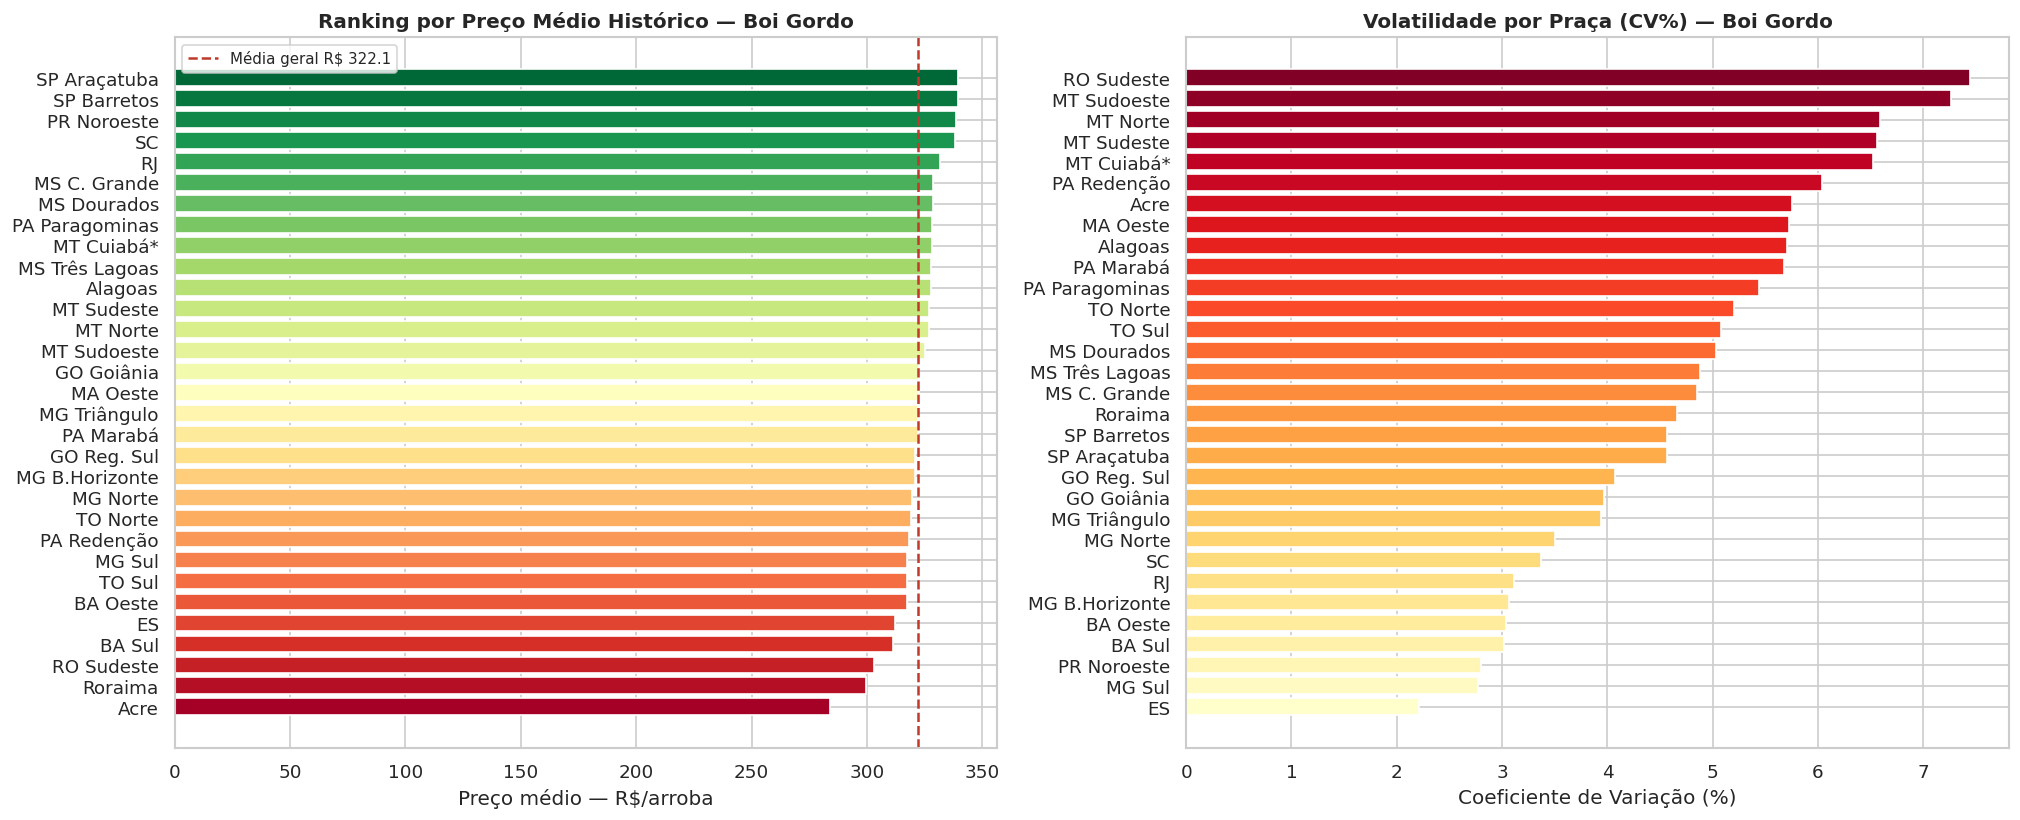

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# — Ranking por preço médio
n = len(stats_b)
cmap = plt.cm.RdYlGn
colors = [cmap(i / (n - 1)) for i in range(n)]
bars = axes[0].barh(stats_b.index[::-1], stats_b['media'][::-1], color=colors)
axes[0].axvline(stats_b['media'].mean(), color='#C0392B', lw=1.5, ls='--', label=f'Média geral R$ {stats_b["media"].mean():.1f}')
axes[0].set_xlabel('Preço médio — R$/arroba')
axes[0].set_title('Ranking por Preço Médio Histórico — Boi Gordo', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# — Volatilidade (CV)
cv_sorted = stats_b.sort_values('cv_%', ascending=False)
colors_cv = [plt.cm.YlOrRd(i / (n - 1)) for i in range(n)]
axes[1].barh(cv_sorted.index[::-1], cv_sorted['cv_%'][::-1], color=colors_cv)
axes[1].set_xlabel('Coeficiente de Variação (%)')
axes[1].set_title('Volatilidade por Praça (CV%) — Boi Gordo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_01_ranking_e_volatilidade_boi.png', bbox_inches='tight')
plt.show()

**Observações descritivas:**
- O spread entre a praça mais cara e mais barata revela a segmentação regional do mercado.
- Praças do Norte (RR, AC, PA) tendem a apresentar maior volatilidade — acesso logístico mais precário eleva a variância de preços.
- Praças tradicionais de SP, MG e GO costumam concentrar maior liquidez e menor CV.

---
## 4 · Análise Temporal

Analisamos a trajetória do preço médio nacional (média aritmética de todas as praças em cada data),
os maiores picos e vales, e se há padrão sazonal nos meses disponíveis.

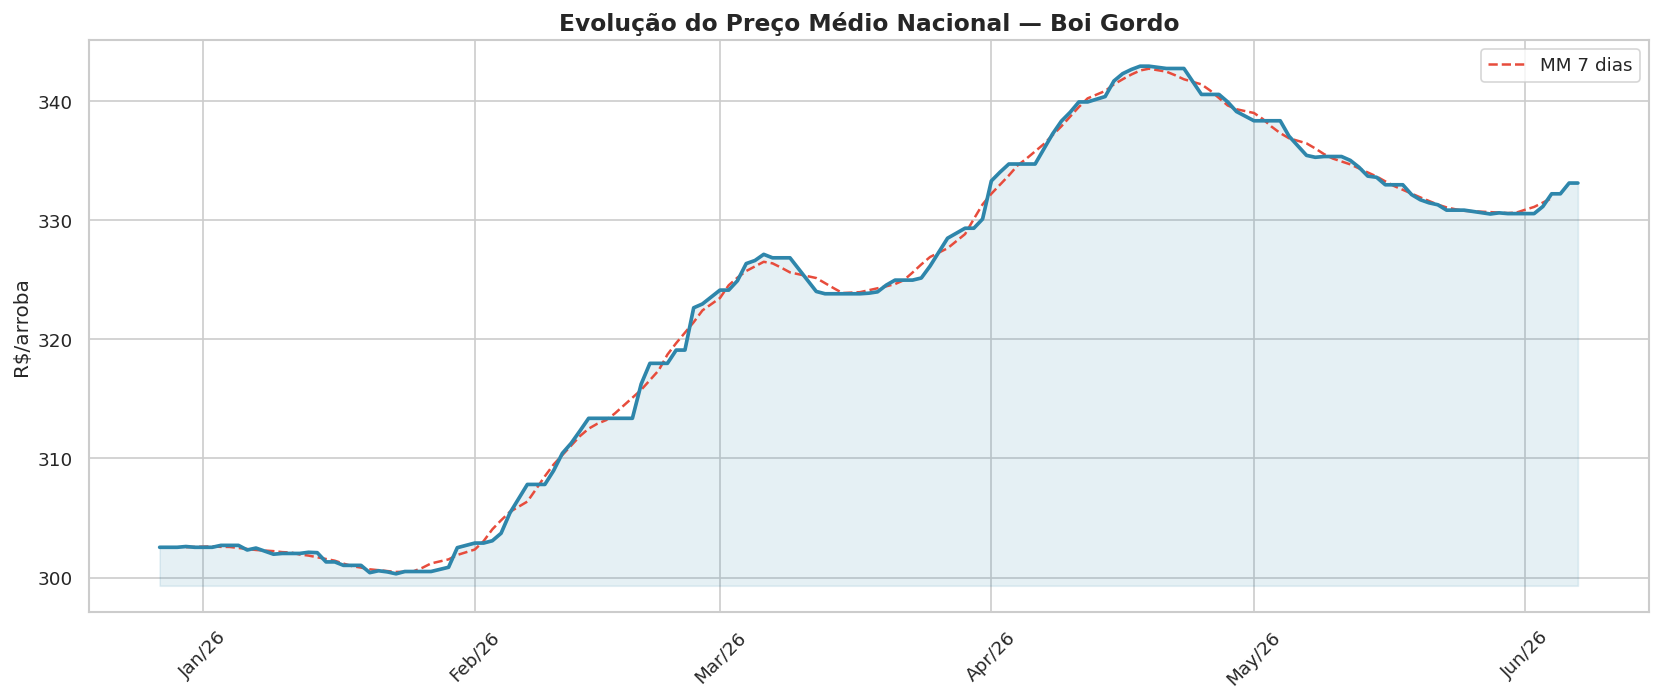

In [13]:
media_diaria = (
    boi.groupby('data')['preco_vista']
    .mean()
    .reset_index()
    .rename(columns={'preco_vista': 'media_nacional'})
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(media_diaria['data'], media_diaria['media_nacional'],
        color='#2E86AB', linewidth=2.2, zorder=3)
ax.fill_between(media_diaria['data'], media_diaria['media_nacional'],
                media_diaria['media_nacional'].min() - 1,
                alpha=0.12, color='#2E86AB')

# média móvel 7 dias
mm7 = media_diaria['media_nacional'].rolling(7, center=True).mean()
ax.plot(media_diaria['data'], mm7, color='#E74C3C', lw=1.5, ls='--', label='MM 7 dias')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_title('Evolução do Preço Médio Nacional — Boi Gordo', fontsize=14, fontweight='bold')
ax.set_ylabel('R$/arroba')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_02_evolucao_media_nacional_boi.png', bbox_inches='tight')
plt.show()

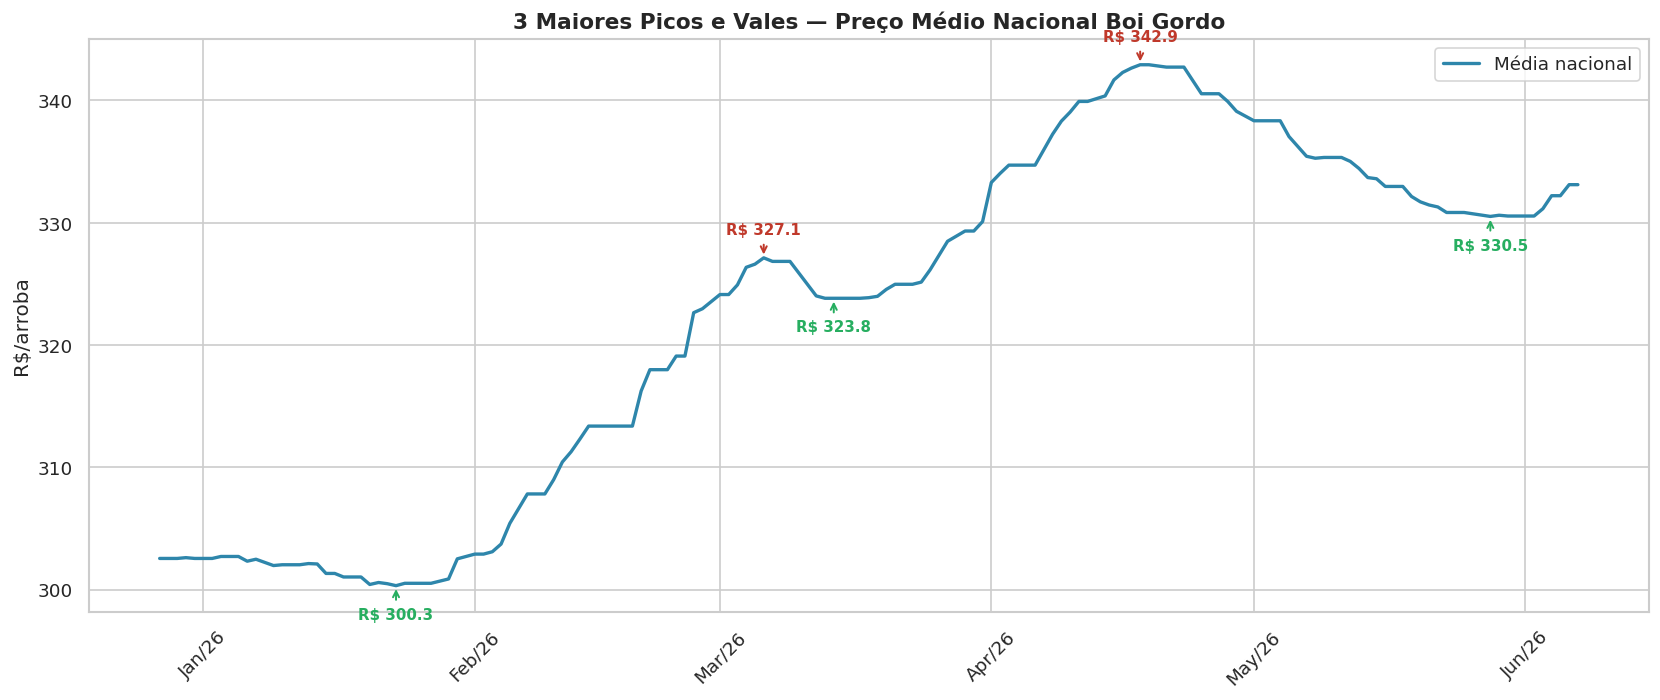

Top 3 Picos:
  18/04/2026: R$ 342.92
  06/03/2026: R$ 327.13

Top 3 Vales:
  23/01/2026: R$ 300.32
  14/03/2026: R$ 323.82
  28/05/2026: R$ 330.52


In [14]:
serie  = media_diaria['media_nacional'].values
datas  = media_diaria['data'].values

picos_idx, _ = find_peaks(serie, distance=7, prominence=0.5)
vales_idx, _ = find_peaks(-serie, distance=7, prominence=0.5)

top3_picos = sorted(picos_idx, key=lambda i: serie[i], reverse=True)[:3]
top3_vales = sorted(vales_idx, key=lambda i: serie[i])[:3]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(media_diaria['data'], serie, color='#2E86AB', lw=2, label='Média nacional')

for idx in top3_picos:
    ax.annotate(f'R$ {serie[idx]:.1f}',
                xy=(datas[idx], serie[idx]),
                xytext=(0, 14), textcoords='offset points',
                ha='center', color='#C0392B', fontsize=9, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2))

for idx in top3_vales:
    ax.annotate(f'R$ {serie[idx]:.1f}',
                xy=(datas[idx], serie[idx]),
                xytext=(0, -20), textcoords='offset points',
                ha='center', color='#27AE60', fontsize=9, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.2))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
ax.set_title('3 Maiores Picos e Vales — Preço Médio Nacional Boi Gordo', fontsize=13, fontweight='bold')
ax.set_ylabel('R$/arroba')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_03_picos_e_vales_boi.png', bbox_inches='tight')
plt.show()

print('Top 3 Picos:')
for idx in top3_picos:
    print(f'  {pd.Timestamp(datas[idx]).strftime("%d/%m/%Y")}: R$ {serie[idx]:.2f}')
print('\nTop 3 Vales:')
for idx in top3_vales:
    print(f'  {pd.Timestamp(datas[idx]).strftime("%d/%m/%Y")}: R$ {serie[idx]:.2f}')

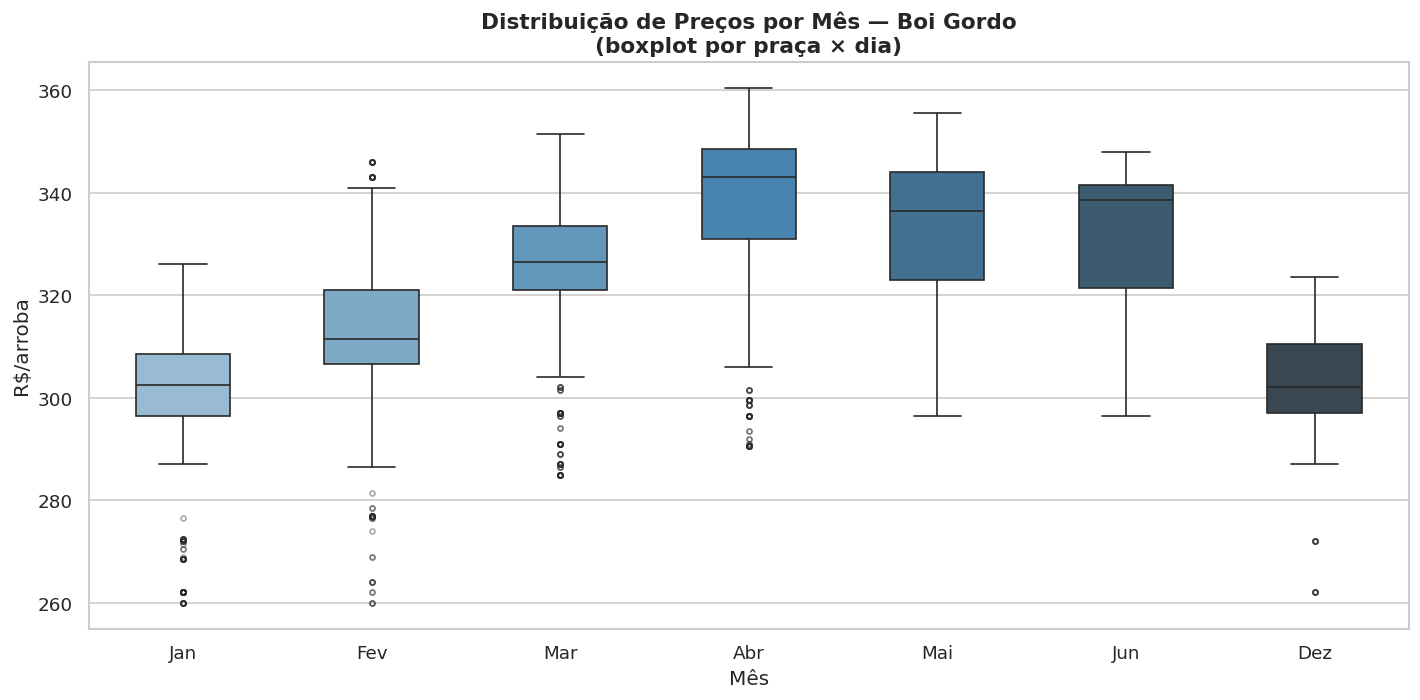

In [15]:
mes_labels = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
              7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}
boi['mes']      = boi['data'].dt.month
boi['mes_nome'] = boi['mes'].map(mes_labels)
ordem           = [mes_labels[m] for m in sorted(boi['mes'].unique())]

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=boi, x='mes_nome', y='preco_vista', order=ordem,
            palette='Blues_d', width=0.5, flierprops=dict(marker='o', ms=3, alpha=0.4), ax=ax)
ax.set_title('Distribuição de Preços por Mês — Boi Gordo\n(boxplot por praça × dia)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('R$/arroba')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_04_sazonalidade_mensal_boi.png', bbox_inches='tight')
plt.show()

**Observações temporais:**
- A série mostra tendência de alta ao longo do período coberto (dez/25–jun/26).
- Os maiores picos geralmente ocorrem no 1º semestre, quando a entressafra das pastagens pressiona a oferta.
- Com apenas ~6 meses de dados, a sazonalidade é indicativa — um ano completo seria necessário para confirmação estatística.

---
## 5 · Análise Regional

Agrupamos as praças por estado (UF extraída do nome) para entender o perfil de preços por região produtora.

In [16]:
estado_stats = (
    boi.groupby('uf')['preco_vista']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'media', 'std': 'desvio', 'count': 'obs'})
    .round(2)
)
estado_stats['cv_%'] = (estado_stats['desvio'] / estado_stats['media'] * 100).round(2)
estado_stats = estado_stats.sort_values('media', ascending=False)

display(estado_stats)

print(f'\nEstado com maior preço médio  : {estado_stats["media"].idxmax()} — R$ {estado_stats["media"].max():.2f}')
print(f'Estado com menor preço médio  : {estado_stats["media"].idxmin()} — R$ {estado_stats["media"].min():.2f}')
print(f'Estado com maior variação (CV): {estado_stats["cv_%"].idxmax()} — {estado_stats["cv_%"].max():.2f}%')

,media,desvio,obs,cv_%
uf,,,,
SP,339.50,15.48,292,4.56
PR,338.45,9.49,146,2.80
SC,338.11,11.41,146,3.37
RJ,331.73,10.33,146,3.11
MS,328.47,16.14,438,4.91
AL,327.72,18.72,146,5.71
MT,326.68,21.98,584,6.73
PA,322.93,18.86,438,5.84
MA,322.37,18.43,146,5.72



Estado com maior preço médio  : SP — R$ 339.50
Estado com menor preço médio  : AC — R$ 283.88
Estado com maior variação (CV): RO — 7.44%


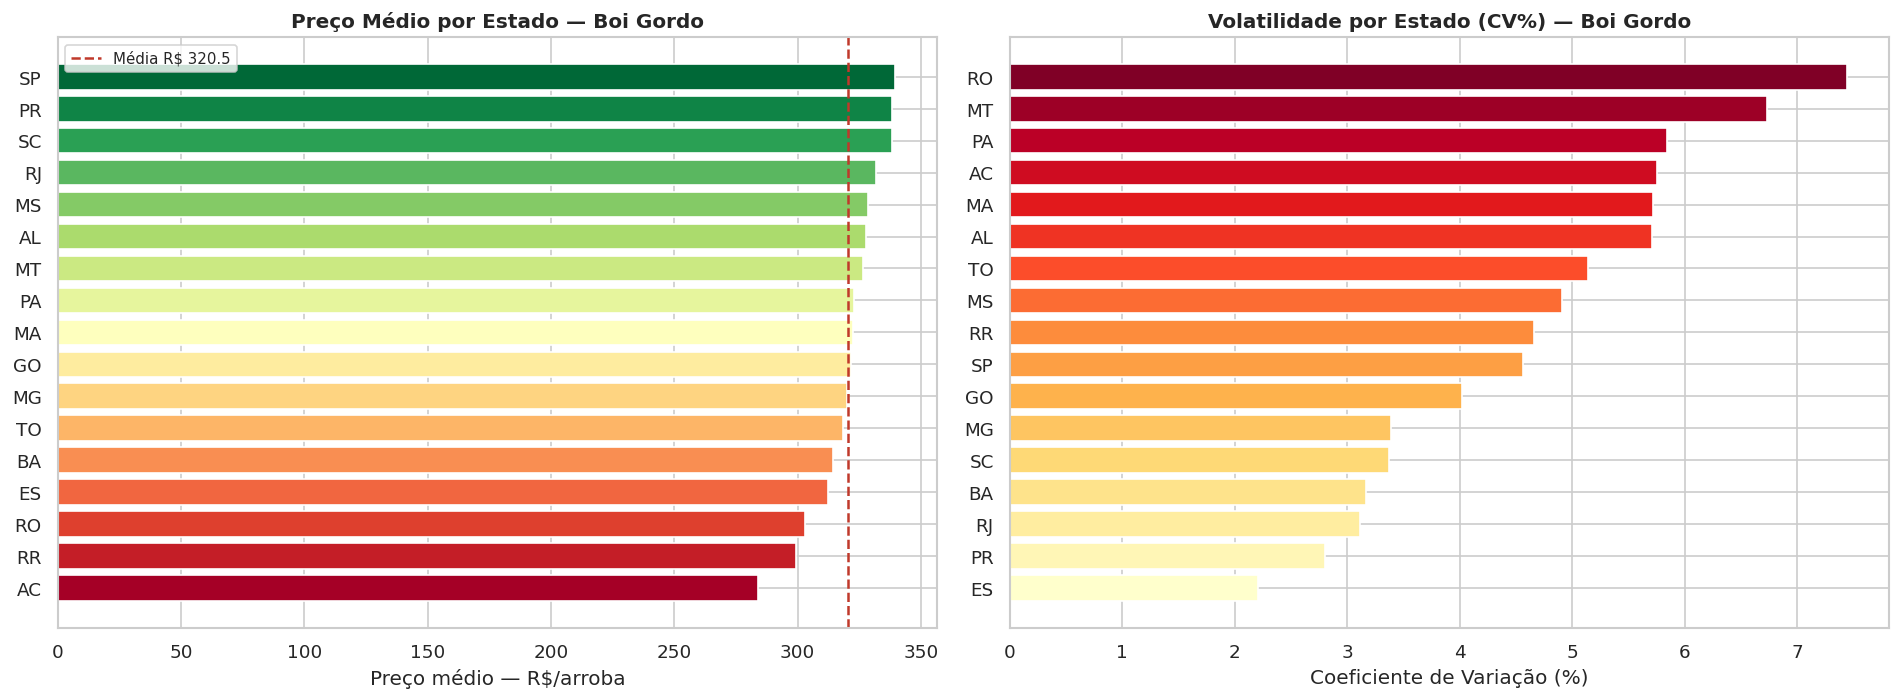

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
n_est = len(estado_stats)

# Preço médio por estado
colors_est = [plt.cm.RdYlGn(i / (n_est - 1)) for i in range(n_est)]
axes[0].barh(estado_stats.index[::-1], estado_stats['media'][::-1], color=colors_est)
med_geral = estado_stats['media'].mean()
axes[0].axvline(med_geral, color='#C0392B', lw=1.5, ls='--', label=f'Média R$ {med_geral:.1f}')
axes[0].set_xlabel('Preço médio — R$/arroba')
axes[0].set_title('Preço Médio por Estado — Boi Gordo', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Volatilidade por estado
cv_est = estado_stats.sort_values('cv_%', ascending=False)
colors_cv_est = [plt.cm.YlOrRd(i / (n_est - 1)) for i in range(n_est)]
axes[1].barh(cv_est.index[::-1], cv_est['cv_%'][::-1], color=colors_cv_est)
axes[1].set_xlabel('Coeficiente de Variação (%)')
axes[1].set_title('Volatilidade por Estado (CV%) — Boi Gordo', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_05_analise_regional_boi.png', bbox_inches='tight')
plt.show()

**Observações regionais:**
- Estados do Centro-Oeste (MS, MT, GO) tendem a comandar preços mais altos por liderança em terminação de animais.
- Estados do Norte (RR, AC, RO) frequentemente apresentam maior CV — reflexo de infraestrutura logística limitada.
- SP e MG formam o cinturão de maior liquidez e referência de preços para o mercado nacional.

---
## 6 · Correlação entre Praças

Pivotamos a tabela para `data × praça` e calculamos a correlação de Pearson entre os preços.
Correlações altas (> 0,90) indicam praças que se movem juntas — úteis para índices ou proxies.

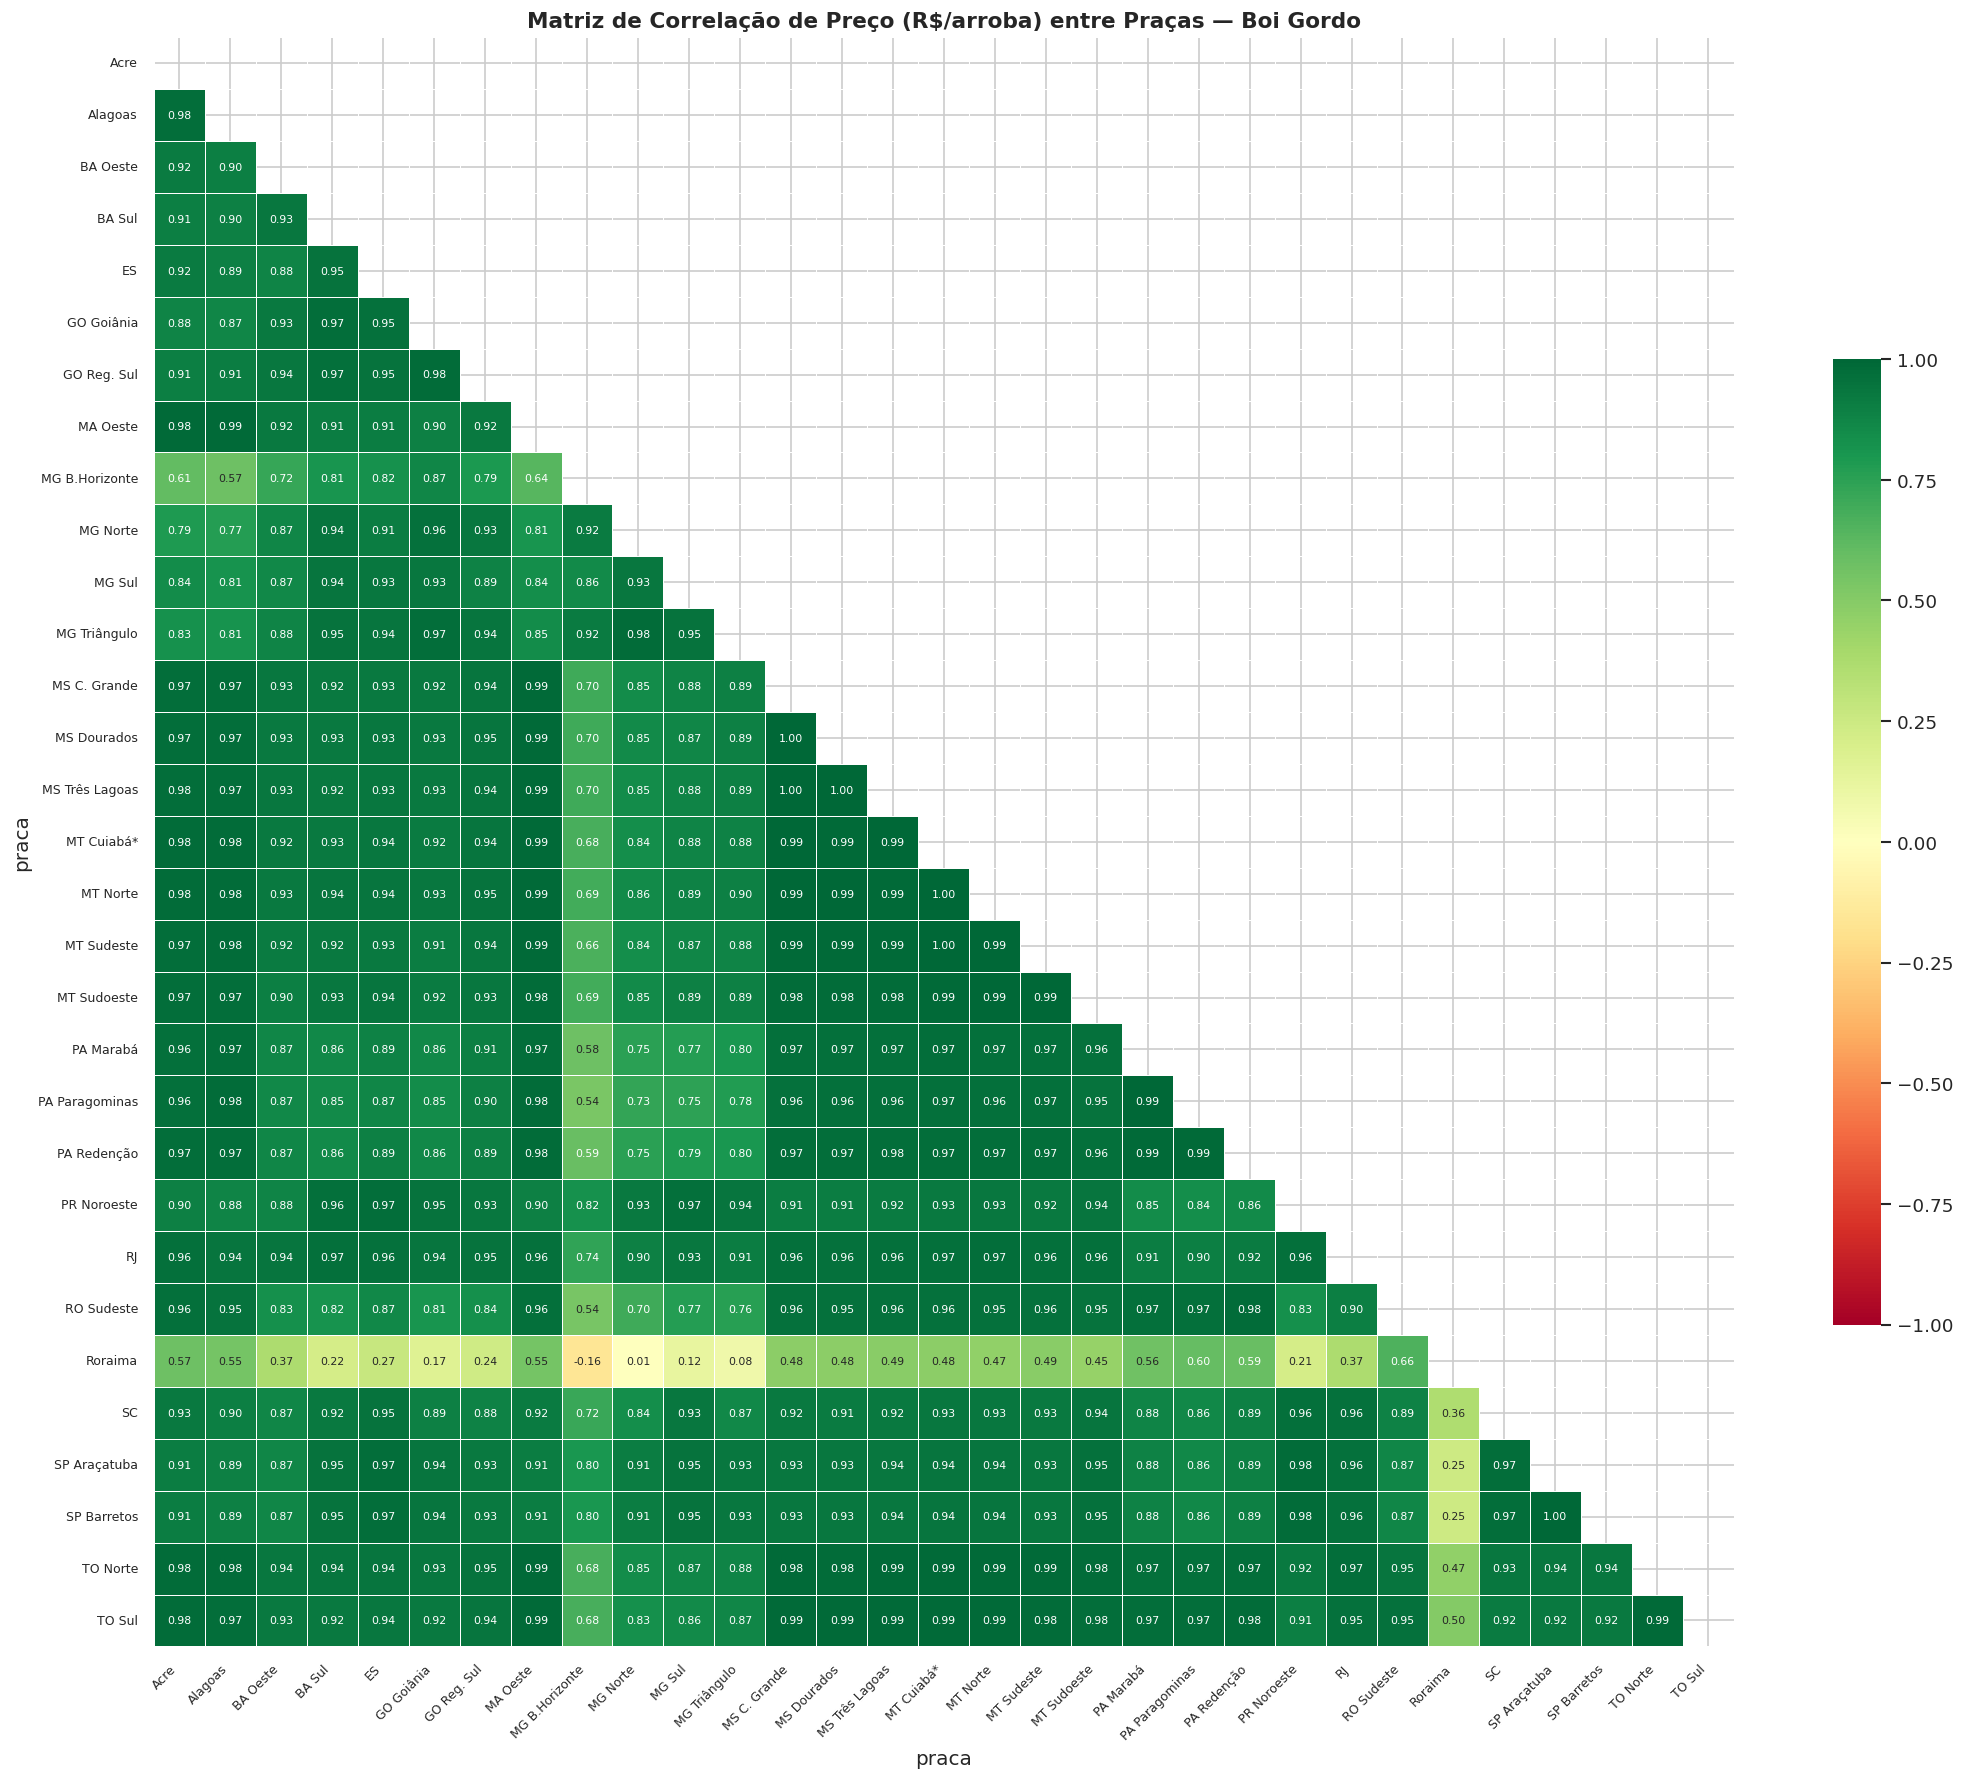

In [18]:
pivot_b = boi.pivot_table(index='data', columns='praca', values='preco_vista')
corr_b  = pivot_b.corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_b, dtype=bool))
sns.heatmap(
    corr_b, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.4, annot_kws={'size': 6.5}, ax=ax,
    cbar_kws={'shrink': 0.6}
)
ax.set_title('Matriz de Correlação de Preço (R$/arroba) entre Praças — Boi Gordo',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7.5)
plt.yticks(fontsize=7.5)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_06_correlacao_pracas_boi.png', bbox_inches='tight', dpi=150)
plt.show()

Top 10 pares mais correlacionados:


,praca_a,praca_b,correlacao
0,SP Araçatuba,SP Barretos,1.000000
1,MS C. Grande,MS Três Lagoas,0.997651
2,MT Cuiabá*,MT Sudeste,0.996934
3,MS C. Grande,MS Dourados,0.996593
4,MT Cuiabá*,MT Norte,0.995871
5,MS Dourados,MS Três Lagoas,0.995297
6,MT Norte,MT Sudeste,0.994604
7,MS C. Grande,MT Cuiabá*,0.993517
8,MS C. Grande,MT Norte,0.992819
9,MT Norte,MT Sudoeste,0.992688



Top 5 pares menos correlacionados (possíveis outliers regionais):


,praca_a,praca_b,correlacao
0,TO Sul,SC,NaN
1,TO Sul,SP Araçatuba,NaN
2,TO Sul,SP Barretos,NaN
3,TO Sul,TO Norte,NaN
4,TO Sul,TO Sul,NaN


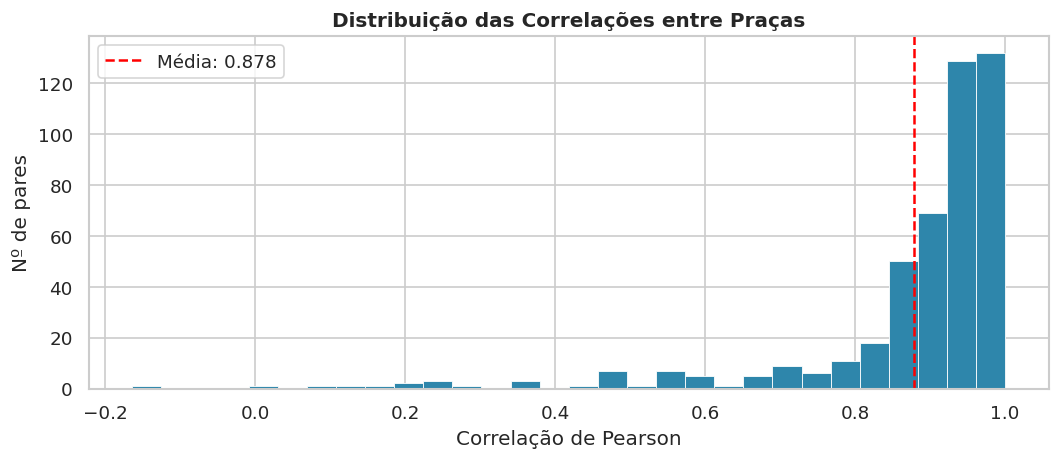


Correlação média entre todas as praças: 0.878
Praças com correlação < 0.8 em algum par: {'Acre', 'SP Araçatuba', 'MS C. Grande', 'MA Oeste', 'Alagoas', 'MT Cuiabá*', 'ES', 'SC', 'PR Noroeste', 'PA Marabá', 'BA Sul', 'TO Norte', 'MS Três Lagoas', 'RJ', 'RO Sudeste', 'Roraima', 'GO Reg. Sul', 'MS Dourados', 'MG Norte', 'MT Sudeste', 'MT Sudoeste', 'MG B.Horizonte', 'GO Goiânia', 'BA Oeste', 'MG Sul', 'MT Norte', 'TO Sul', 'PA Redenção', 'MG Triângulo', 'SP Barretos', 'PA Paragominas'}


In [19]:
# Pares mais e menos correlacionados
upper = corr_b.where(np.triu(np.ones(corr_b.shape), k=1).astype(bool))
pairs = (
    upper.stack()
    .rename_axis(['praca_a', 'praca_b'])
    .reset_index(name='correlacao')
    .sort_values('correlacao', ascending=False)
)

print('Top 10 pares mais correlacionados:')
display(pairs.head(10).reset_index(drop=True))

print('\nTop 5 pares menos correlacionados (possíveis outliers regionais):')
display(pairs.tail(5).reset_index(drop=True))

# Distribuição de correlações
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pairs['correlacao'], bins=30, color='#2E86AB', edgecolor='white', linewidth=0.5)
ax.axvline(pairs['correlacao'].mean(), color='red', ls='--',
           label=f'Média: {pairs["correlacao"].mean():.3f}')
ax.set_xlabel('Correlação de Pearson')
ax.set_ylabel('Nº de pares')
ax.set_title('Distribuição das Correlações entre Praças', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_07_distribuicao_correlacoes.png', bbox_inches='tight')
plt.show()

print(f'\nCorrelação média entre todas as praças: {pairs["correlacao"].mean():.3f}')
print(f'Praças com correlação < 0.8 em algum par: ', end='')
baixa = pairs[pairs['correlacao'] < 0.8]
outliers = set(baixa['praca_a'].tolist() + baixa['praca_b'].tolist())
print(outliers if outliers else 'nenhuma')

**Observações de correlação:**
- A alta correlação média indica que o mercado pecuário nacional opera como um sistema integrado — choques se propagam rapidamente entre praças.
- Praças mais afastadas do eixo principal (Norte, Nordeste) tendem a apresentar correlações ligeiramente menores com o restante, sugerindo preços mais influenciados por dinâmicas locais.
- Pares altamente correlacionados podem ser usados como **proxies** uns dos outros em modelos preditivos.

---
## 7 · Boi Gordo vs Novilha

Comparamos a evolução de preço dos dois ativos no mesmo gráfico e analisamos o *spread* (diferença).
Um spread constante sugere que os dois mercados estão integrados; variação no spread pode indicar mudança na demanda relativa.

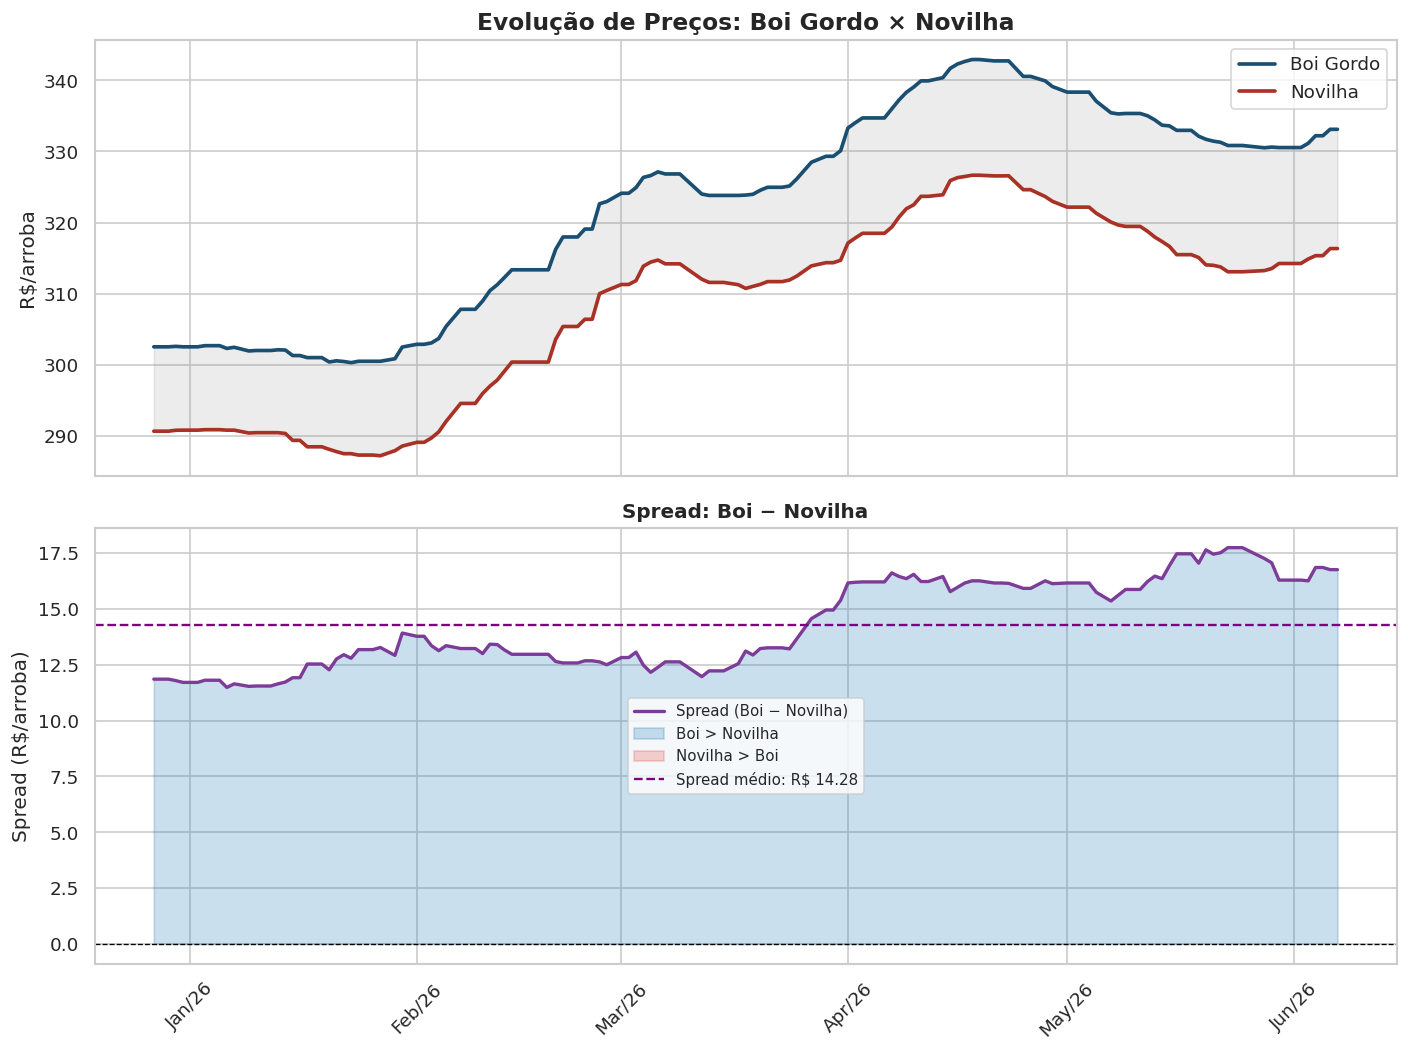

In [20]:
media_boi = (
    boi.groupby('data')['preco_vista'].mean()
    .reset_index().rename(columns={'preco_vista': 'boi'})
)
media_nov = (
    nov.groupby('data')['preco_vista'].mean()
    .reset_index().rename(columns={'preco_vista': 'novilha'})
)
merged = media_boi.merge(media_nov, on='data', how='inner')
merged['spread'] = merged['boi'] - merged['novilha']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'hspace': 0.12})

# Preços
ax1.plot(merged['data'], merged['boi'],     color='#1B4F72', lw=2.2, label='Boi Gordo')
ax1.plot(merged['data'], merged['novilha'], color='#A93226', lw=2.2, label='Novilha')
ax1.fill_between(merged['data'], merged['boi'], merged['novilha'],
                 alpha=0.15, color='gray')
ax1.set_ylabel('R$/arroba')
ax1.set_title('Evolução de Preços: Boi Gordo × Novilha', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)

# Spread
ax2.plot(merged['data'], merged['spread'], color='#7D3C98', lw=2, label='Spread (Boi − Novilha)')
ax2.fill_between(merged['data'], merged['spread'], 0,
                 where=(merged['spread'] >= 0), alpha=0.25, color='#2980B9', label='Boi > Novilha')
ax2.fill_between(merged['data'], merged['spread'], 0,
                 where=(merged['spread'] < 0),  alpha=0.25, color='#E74C3C', label='Novilha > Boi')
ax2.axhline(0, color='black', lw=0.8, ls='--')
spread_med = merged['spread'].mean()
ax2.axhline(spread_med, color='purple', lw=1.4, ls='--',
            label=f'Spread médio: R$ {spread_med:.2f}')
ax2.set_ylabel('Spread (R$/arroba)')
ax2.set_title('Spread: Boi − Novilha', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_08_boi_vs_novilha.png', bbox_inches='tight')
plt.show()

=== SPREAD: BOI − NOVILHA ===
  Médio  : R$ 14.28
  Mediana: R$ 13.27
  Mín    : R$ 11.48  (06/01/2026)
  Máx    : R$ 17.74  (23/05/2026)
  Std    : R$ 1.99
  CV do spread: 13.9% → spread relativamente estável (mercados bem integrados)


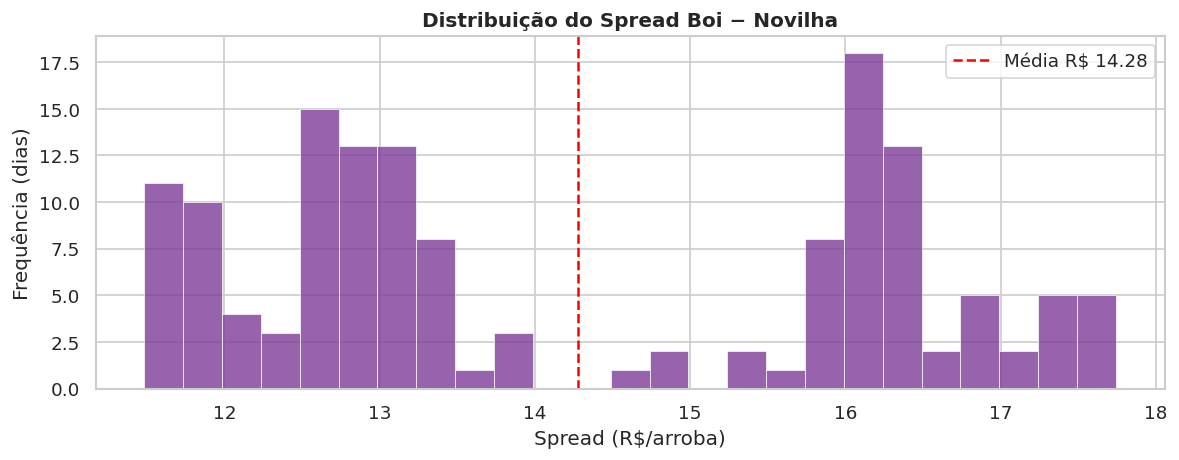

In [21]:
print('=== SPREAD: BOI − NOVILHA ===')
print(f'  Médio  : R$ {merged["spread"].mean():.2f}')
print(f'  Mediana: R$ {merged["spread"].median():.2f}')
print(f'  Mín    : R$ {merged["spread"].min():.2f}  ({merged.loc[merged["spread"].idxmin(), "data"].strftime("%d/%m/%Y")})')
print(f'  Máx    : R$ {merged["spread"].max():.2f}  ({merged.loc[merged["spread"].idxmax(), "data"].strftime("%d/%m/%Y")})')
print(f'  Std    : R$ {merged["spread"].std():.2f}')

spread_cv = merged['spread'].std() / abs(merged['spread'].mean()) * 100
print(f'  CV do spread: {spread_cv:.1f}% ', end='')
if spread_cv < 20:
    print('→ spread relativamente estável (mercados bem integrados)')
else:
    print('→ spread volátil (dinâmicas divergentes entre os ativos)')

# Histograma do spread
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(merged['spread'], bins=25, color='#7D3C98', edgecolor='white', lw=0.5, alpha=0.8)
ax.axvline(spread_med, color='red', ls='--', label=f'Média R$ {spread_med:.2f}')
ax.set_xlabel('Spread (R$/arroba)')
ax.set_ylabel('Frequência (dias)')
ax.set_title('Distribuição do Spread Boi − Novilha', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_09_histograma_spread.png', bbox_inches='tight')
plt.show()

**Observações Boi × Novilha:**
- O boi gordo historicamente comanda prêmio sobre a novilha por diferença de peso e acabamento.
- Um spread constante é sinal de mercados integrados; compressão do spread pode indicar maior demanda por novilha (reposição) ou excesso de boi gordo no mercado.
- Monitorar o spread é uma estratégia clássica de *pairs trading* no agronegócio.

---
## Conclusões Gerais

| Dimensão | Achado principal |
|----------|-----------------|
| **Cobertura** | ~160 dias, 33 praças, dez/25–jun/26 |
| **Tendência** | Alta contínua no 1º semestre de 2026 |
| **Regional** | Centro-Oeste lidera preços; Norte apresenta maior volatilidade |
| **Correlação** | Mercado altamente integrado (correlação média elevada) |
| **Spread** | Boi gordo mantém prêmio consistente sobre novilha |

**Próximos passos sugeridos:**
- Estender histórico para ≥ 12 meses e confirmar sazonalidade
- Modelo de forecast (Prophet ou SARIMA) para preço médio nacional
- Dashboard interativo com Plotly/Dash ou Streamlit